### By downloading data
https://hub.scag.ca.gov/datasets/3e9c888c6aae45ab8e140abeec42cd1e_0/about

In [78]:
import zipfile

with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
    zip_ref.extractall("Data/")

luGdf = gpd.read_file("Data/landuse.gpkg")

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/landuse.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [28]:
selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
luGdf = luGdf[selected_cols]

In [44]:
luGdf

,ACRES,GEOID20,DEN_AVG,ZN19_SCAG,LU19,geometry,LU19_major_code,LU19_major_label,area_m2
0,0.222311,060371132321019,4.5,1111,1110.0,"MULTIPOLYGON (((350737.273 3787751.664, 350737...",1100.0,Residential,899.661199
1,0.227461,060371132321019,4.5,1111,1110.0,"MULTIPOLYGON (((350736.997 3787731.395, 350737...",1100.0,Residential,920.500014
2,0.221317,060371132321019,4.5,1111,1110.0,"MULTIPOLYGON (((350731.662 3787710.984, 350732...",1100.0,Residential,895.639876
3,0.271077,060371132321019,3.5,1111,1110.0,"MULTIPOLYGON (((350521.208 3787753.444, 350522...",1100.0,Residential,1097.008942
4,0.341507,060371132321019,3.5,1111,1110.0,"MULTIPOLYGON (((350521.208 3787753.444, 350506...",1100.0,Residential,1382.030011
...,...,...,...,...,...,...,...,...,...
2406368,2.048322,060374033271017,0.0,1300,3100.0,"MULTIPOLYGON (((423748.455 3764513.293, 423682...",3100.0,NaN,8289.271337
2406369,0.126775,060371835101004,6.5,1111,1110.0,"MULTIPOLYGON (((388846.009 3775726.33, 388845....",1100.0,Residential,513.038838
2406370,0.068799,060375750012013,0.0,1110,NaN,"MULTIPOLYGON (((393376.57 3739866.886, 393382....",NaN,NaN,278.420568
2406371,0.609390,060379200131007,0.0,1111,3100.0,"MULTIPOLYGON (((360595.271 3809233.113, 360595...",3100.0,NaN,2466.117382


In [32]:
luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')

lu19_major_categories = {
    1100: "Residential",
    1200: "Commercial and Services",
    1300: "Industrial",
    1400: "Transportation, Communications, and Utilities",
    1500: "Public Facilities",
    1600: "Open Space and Recreation",
    1700: "Vacant",
    1800: "Water",
    1900: "Agriculture",
    8888: "Undevelopable or Protected Land",
    9999: "LandUnknown"
}

luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999

luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)

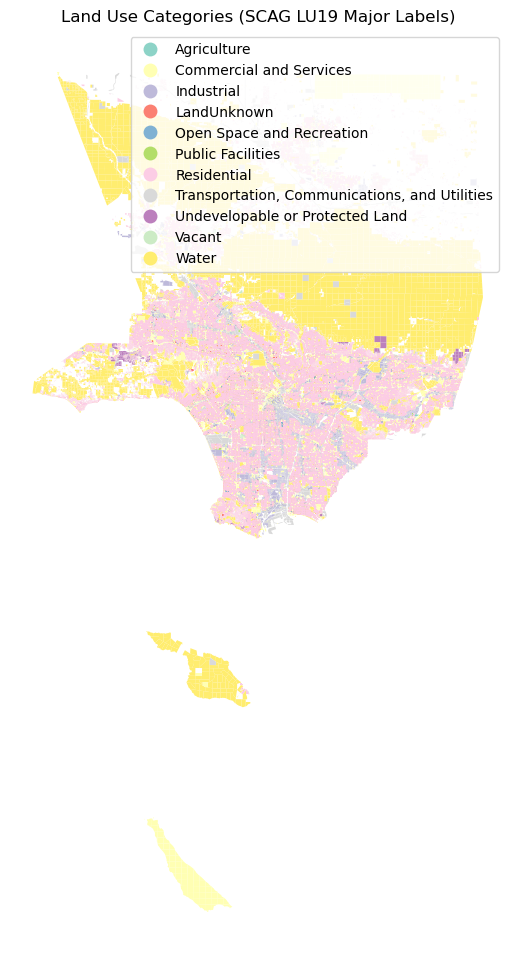

In [35]:
import matplotlib.pyplot as plt

luGdf.plot(column="LU19_major_label", 
           cmap="Set3",              
           legend=True, 
           figsize=(12, 12))

plt.title("Land Use Categories (SCAG LU19 Major Labels)")
plt.axis("off")
plt.show()

#### Calculating the proportion of landuse type for each tract

In [45]:
# making column of GEOID by using the first 11 digit out of 15 digit(block level)
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]

In [47]:
# converting the gdf into meter based projection
luGdf_proj = luGdf.to_crs(epsg=3497)

# making a column that shows the area of each parcel
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

In [48]:
# calculating the area of each landuse type for each tract
# tract_lu has rows that shows the area of each landuse type for each tract (one tract has a couple of rows for each landuse type)
tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()

In [49]:
# calculating the total area for each tract and name it tract_total
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')

In [50]:
# calculating the proportion of each land use type for each census tract
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

In [71]:
# extracting the rows with "Residential"
tract_residential = tract_lu[tract_lu['LU19_major_label'] == 'Residential'][['GEOID', 'percent']]
tract_residential = tract_residential.rename(columns={'percent': 'pct_residential'})

In [72]:
for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

In [74]:
tract_residential = tract_residential.set_index("GEOID")
tracts23 = tracts23.set_index("GEOID")

merged = tracts23.join(tract_residential, how="left")

<Axes: >

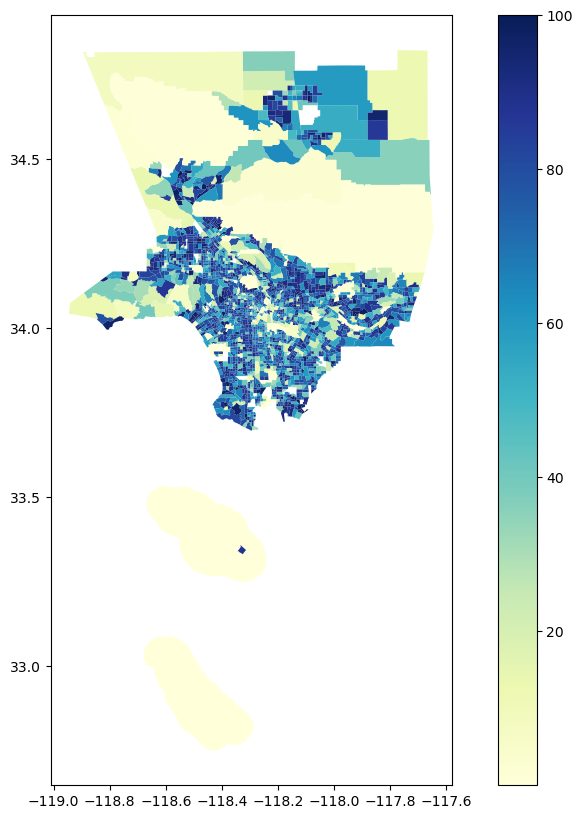

In [75]:
#Mapping
merged.plot(column='pct_residential', cmap='YlGnBu', legend=True, figsize=(12, 10))

### By API

In [89]:
import requests
import geopandas as gpd
from shapely.geometry import Polygon

# ベースURLとパラメータ
url = "https://services5.arcgis.com/vYSHcRQuTn4O8o35/arcgis/rest/services/" \
      "2019_Regional_Land_Use_Information_for_Los_Angeles_County/FeatureServer/0/query"

base_params = {
    "where": "1=1",
    "outFields": "ACRES,ZN19_SCAG,LU19,Shape__Area,Shape__Length,DEN_AVG,GEOID20",
    "outSR": 4326,
    "f": "json",
    "returnGeometry": "true",
    "resultRecordCount": 2000  # 最大件数
}

# 全件収集用ループ
records = []
offset = 0
while True:
    params = base_params.copy()
    params["resultOffset"] = offset

    response = requests.get(url, params=params)
    data = response.json()

    features = data.get("features", [])
    if not features:
        break

    for feature in features:
        attrs = feature.get("attributes", {})
        geom_raw = feature.get("geometry")

        # ArcGIS geometry → shapely Polygon
        if isinstance(geom_raw, dict) and "rings" in geom_raw and geom_raw["rings"]:
            try:
                geom = Polygon(geom_raw["rings"][0])  # 外周のみ使用
                attrs["geometry"] = geom
                records.append(attrs)
            except Exception as e:
                continue

    offset += len(features)
    print(f"Downloaded {offset} features...")

    # Safety break (optional)
    if data.get("exceededTransferLimit") is not True:
        break

# GeoDataFrame 作成
ludf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:4326")

Downloaded 2000 features...
Downloaded 4000 features...
Downloaded 6000 features...
Downloaded 8000 features...
Downloaded 10000 features...
Downloaded 12000 features...
Downloaded 14000 features...
Downloaded 16000 features...
Downloaded 18000 features...
Downloaded 20000 features...
Downloaded 22000 features...
Downloaded 24000 features...
Downloaded 26000 features...
Downloaded 28000 features...
Downloaded 30000 features...
Downloaded 32000 features...
Downloaded 34000 features...
Downloaded 36000 features...
Downloaded 38000 features...
Downloaded 40000 features...
Downloaded 42000 features...
Downloaded 44000 features...
Downloaded 46000 features...
Downloaded 48000 features...
Downloaded 50000 features...
Downloaded 52000 features...
Downloaded 54000 features...
Downloaded 56000 features...
Downloaded 58000 features...
Downloaded 60000 features...
Downloaded 62000 features...
Downloaded 64000 features...
Downloaded 66000 features...
Downloaded 68000 features...
Downloaded 70000 f

KeyboardInterrupt: 

### By OSM

In [ ]:
import osmnx as ox

# to manipulate data
import pandas as pd

# for interactive plots
import plotly.express as px

# to manipulate and visualize spatial data
import geopandas as gpd

# to provide basemaps 
import contextily as ctx

# to give more power to your figures (plots)
import matplotlib.pyplot as plt

In [ ]:
import osmnx as ox

# 建物用途データを取得（例：Beverly Hills）
gdf = ox.features_from_place(
    "Beverly Hills, Los Angeles County, California",
    tags={"building": True}
)

In [ ]:
import matplotlib.pyplot as plt

# landuseの種類を色分けしてプロット
gdf.plot(column="building", cmap="Set3", legend=True, figsize=(10,10))
plt.title("Building types in Beverly Hills")
plt.show()